# Part 2. Time series preprocessing - exercise
We are going to practice what we have learnt in preprocessing and analysis lessons. Using a challenge dataset from Kaggle we are going to preprocess the dataset for a forecasting task. We may not know what forecasting is yet, but we have all the tools available to make the preprocessing.

## Dataset
You can find the target dataset at the [kaggle electric-power-consumption-data-set](https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set). The dataset contains measures of electic power consumption in a single household. Try to infer as much information from the data by yourself even before downloading the dataset.

## Objective
Your task is to prepare a dataframe and save it as a .csv file. The dataframe must have rows with sliding windows for all the variables and the window size is w=5min. Thus, there must be a column for the timestamp at $t$ and a column with each variable $Z^{(i)}$ where $Z^{(i)}=\{Z^{(i)}_t, Z^{(i)}_{t-1}, Z^{(i)}_{t-2}, ..., Z^{(i)}_{t-w}\}$ and $i$ is the identifier of the variable. Preprocess the dataset as best as you can using the techniques learned during the previous lesson. Begin with:
- Plot the variables, including advanced plots
- Perform a simple EDA

And keep an eye out for:
- Missing data
- Magnitudes of the variables
- Stationarity
- Seasonality
- Trend

Use whatever means necessary to achieve a high-quality preprocessing!

In [58]:
import pandas as pd
import numpy as np

In [59]:
file = "/home/eder/projects/temporal-series/data/household_power_consumption.txt"
df = pd.read_csv(file, delimiter=";", header=0)
df.head()

/tmp/ipykernel_45521/505719235.py:2: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, delimiter=";", header=0)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
df.shape

(2075259, 9)

In [4]:
df.describe()

,Sub_metering_3
count,2.049280e+06
mean,6.458447e+00
std,8.437154e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [5]:
df.dtypes

Date                      object
Time                      object
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object

In [60]:
index_col = np.arange(1, df.shape[0] + 1)

In [61]:
df["index_col"] = index_col

In [80]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,index_col
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0,1
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0,2
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0,3
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0,4
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0,5


# Plots

In [20]:
from ydata_profiling import ProfileReport

/home/eder/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
#profile = ProfileReport (df. sample (10000) )
#profile.to_file('report.html')

In [22]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'index_col'],
      dtype='object')

In [36]:
df[df["Global_active_power"] == "?"]

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
6839,21/12/2006,11:23:00,?,?,?,?,?,?,NaN
6840,21/12/2006,11:24:00,?,?,?,?,?,?,NaN
19724,30/12/2006,10:08:00,?,?,?,?,?,?,NaN
19725,30/12/2006,10:09:00,?,?,?,?,?,?,NaN
41832,14/1/2007,18:36:00,?,?,?,?,?,?,NaN
...,...,...,...,...,...,...,...,...,...
1990185,28/9/2010,19:09:00,?,?,?,?,?,?,NaN
1990186,28/9/2010,19:10:00,?,?,?,?,?,?,NaN
1990187,28/9/2010,19:11:00,?,?,?,?,?,?,NaN
1990188,28/9/2010,19:12:00,?,?,?,?,?,?,NaN


In [5]:
df_plot = df[df != "?"]

In [6]:
cols = df_plot.columns
cols = cols[2:]
cols = cols[:-1]
for col in cols:
    df_plot[col] = df_plot.Global_active_power.astype("float")

In [27]:
df_plot.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,index_col
0,16/12/2006,17:24:00,4.216,4.216,4.216,4.216,4.216,4.216,4.216,1
1,16/12/2006,17:25:00,5.360,5.360,5.360,5.360,5.360,5.360,5.360,2
2,16/12/2006,17:26:00,5.374,5.374,5.374,5.374,5.374,5.374,5.374,3
3,16/12/2006,17:27:00,5.388,5.388,5.388,5.388,5.388,5.388,5.388,4
4,16/12/2006,17:28:00,3.666,3.666,3.666,3.666,3.666,3.666,3.666,5


/tmp/ipykernel_27967/3545456482.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels (), rotation=45)


[Text(-2000.0, 0, '−2000'),
 Text(0.0, 0, '0'),
 Text(2000.0, 0, '2000'),
 Text(4000.0, 0, '4000'),
 Text(6000.0, 0, '6000'),
 Text(8000.0, 0, '8000'),
 Text(10000.0, 0, '10000'),
 Text(12000.0, 0, '12000')]

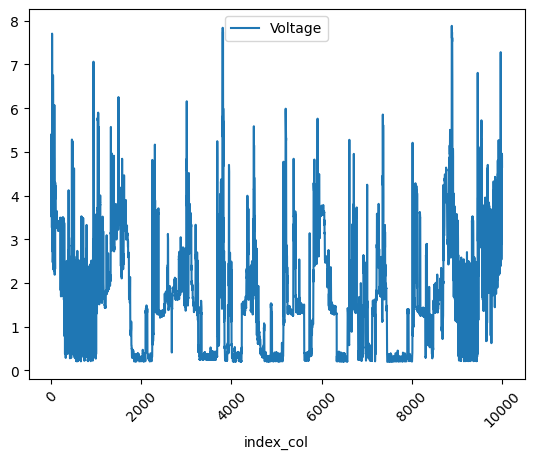

In [33]:
ax = df_plot.iloc[:10000].plot (x='index_col',y='Voltage')
ax.set_xticklabels(ax.get_xticklabels (), rotation=45)

/tmp/ipykernel_27967/1774933338.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels (), rotation=45)
/tmp/ipykernel_27967/1774933338.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels (), rotation=45)
/tmp/ipykernel_27967/1774933338.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels (), rotation=45)
/tmp/ipykernel_27967/1774933338.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels (), rotation=45)
/tmp/ipykernel_27967/1774933338.py:3: UserWarning: set_ticklabels() should only be used with a fixed number 

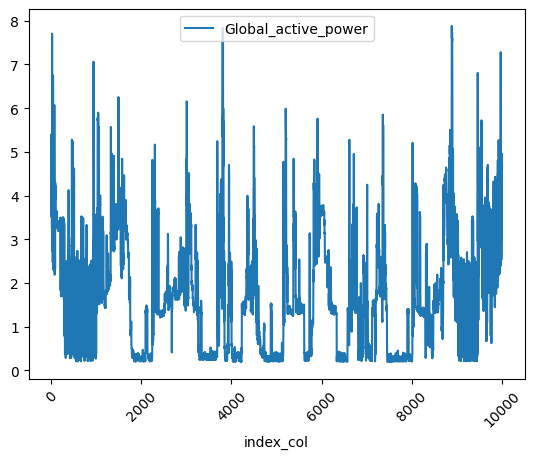

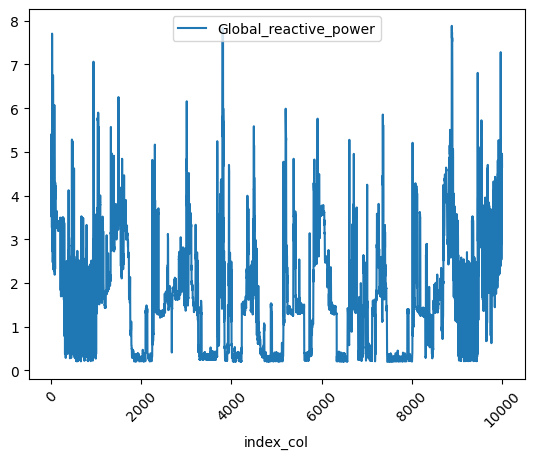

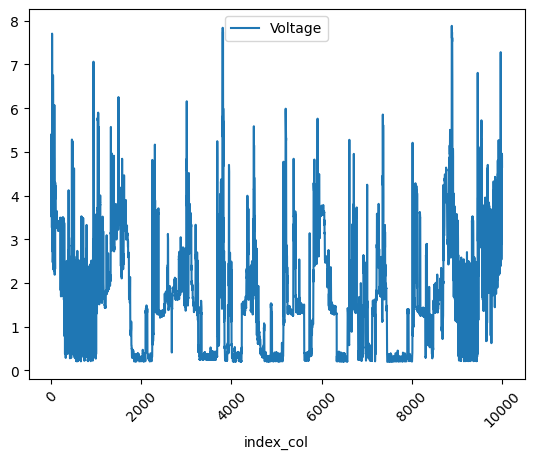

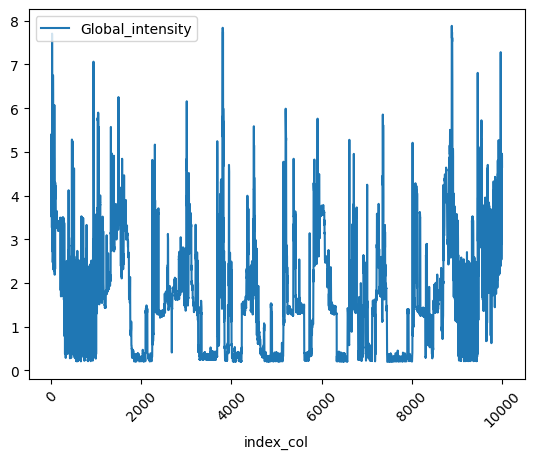

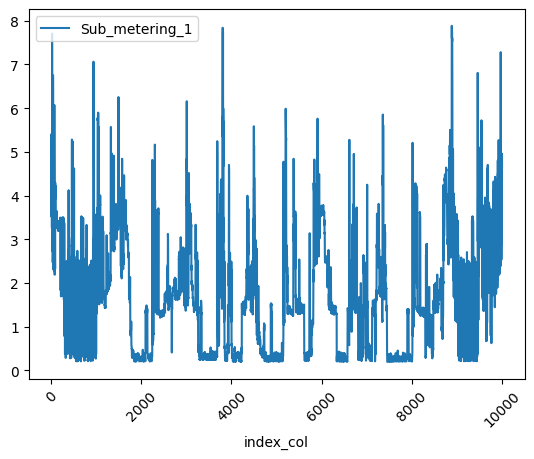

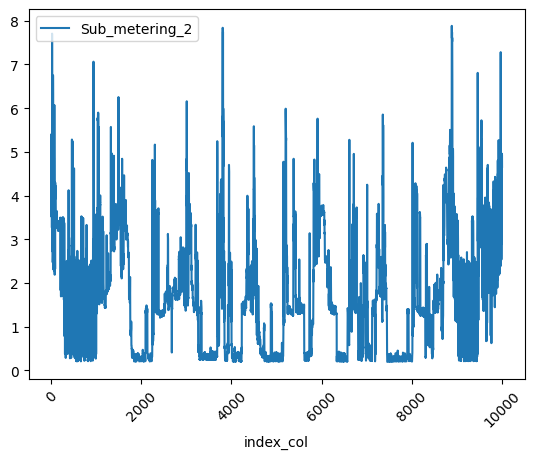

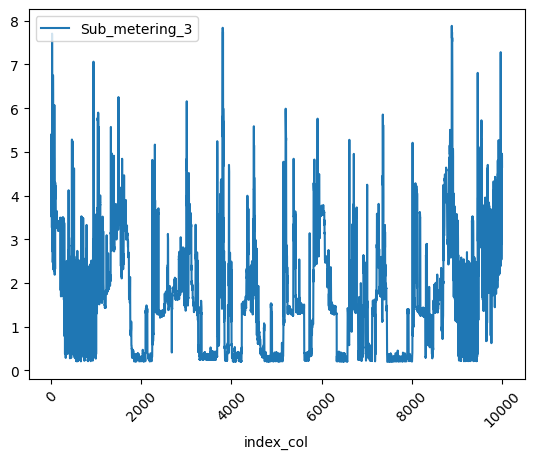

In [34]:
for col in cols:
    ax = df_plot.iloc[:10000].plot (x='index_col',y=col)
    ax.set_xticklabels(ax.get_xticklabels (), rotation=45)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.plot(df_plot["index_col"], df_plot["Global_active_power"])
plt.show()

/tmp/ipykernel_20184/4051361617.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [35]:
df_plot.isna().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
index_col                    0
dtype: int64

<Axes: >

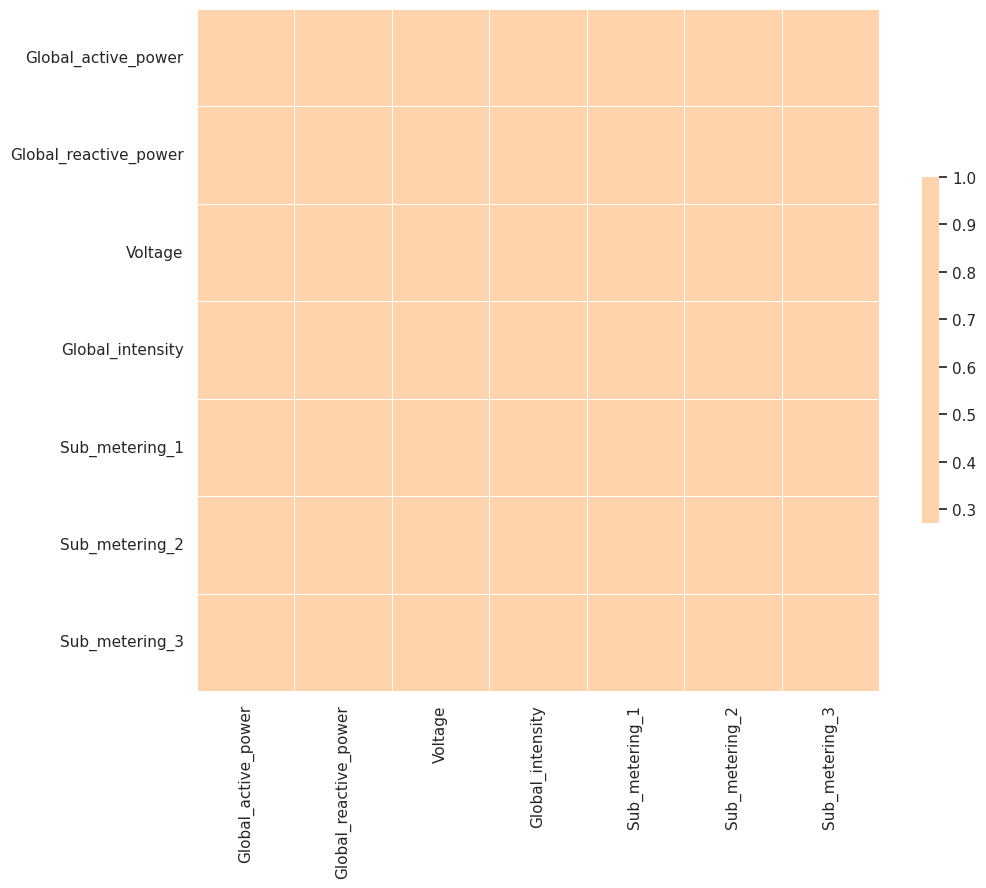

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

# Compute the correlation matrix
corr = df_plot[cols].corr()

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

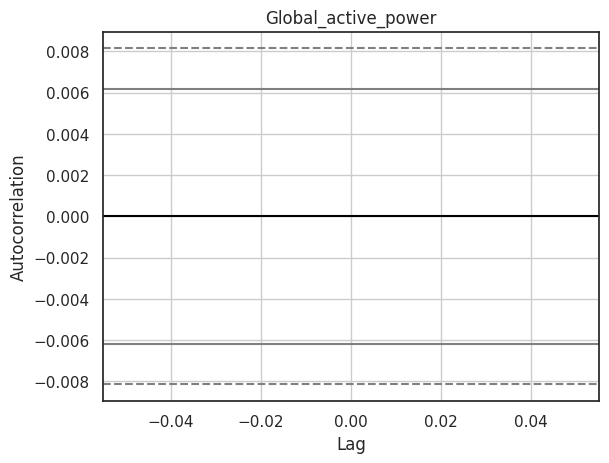

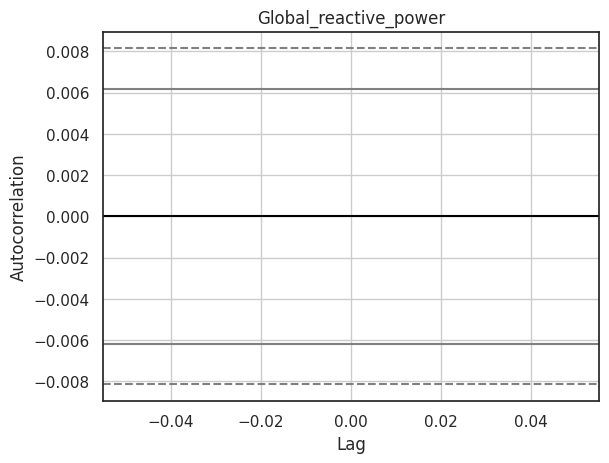

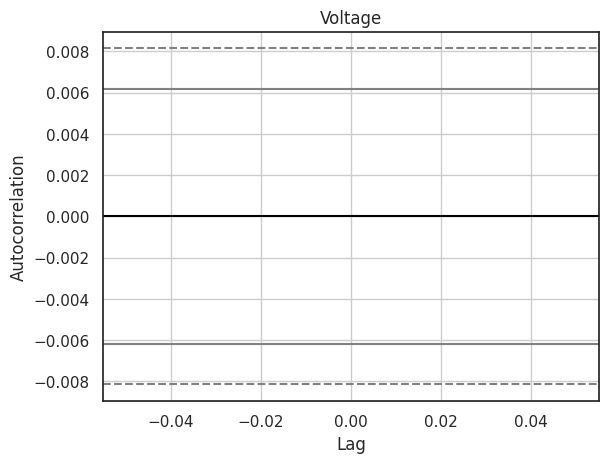

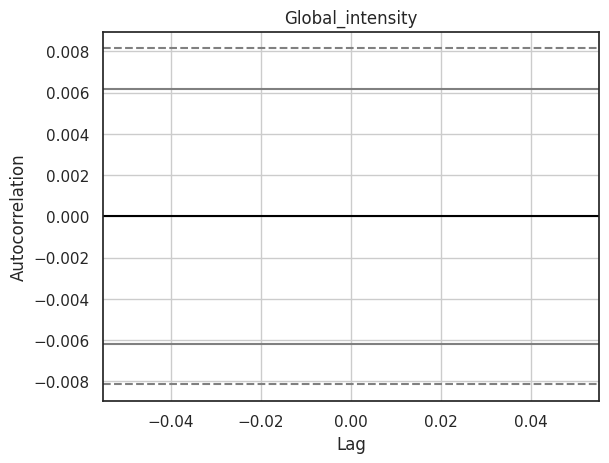

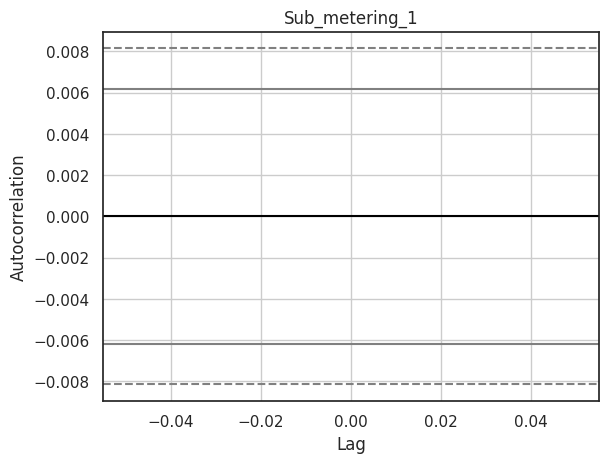

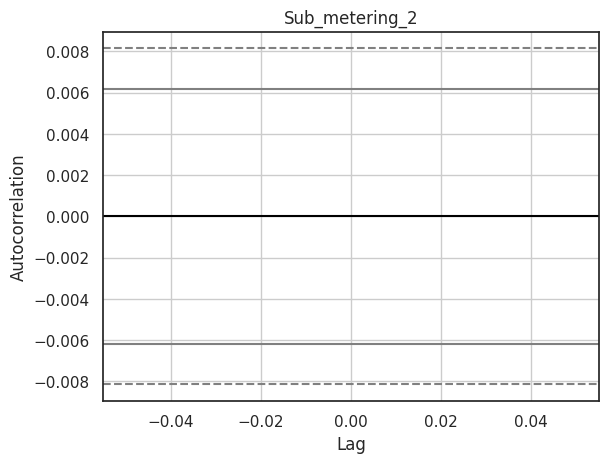

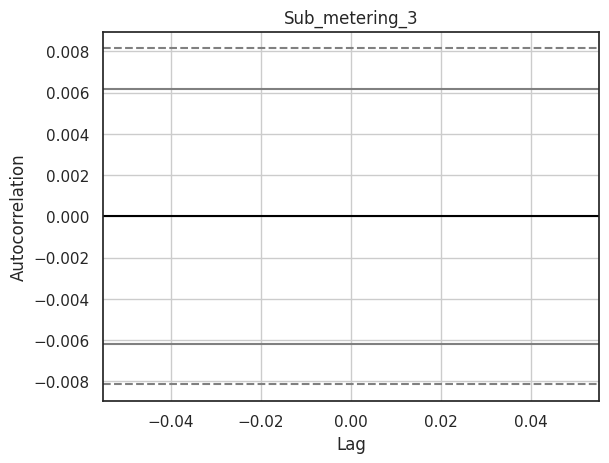

In [46]:
import matplotlib.pyplot as plt

for col in cols:
    fig, ax = plt.subplots()
    pd.plotting.autocorrelation_plot(df_plot[col].iloc[:100000], ax=ax)
    ax.set_title(col)
    plt.show()

# Data cleaning

In [62]:
df[df == "?"]

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,index_col
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2075254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2075255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2075256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2075257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
df2 = df.replace("?", np.nan)

In [64]:
df2[df2 == "?"]

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,index_col
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2075254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2075255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2075256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2075257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
df2.isna().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
index_col                    0
dtype: int64

In [66]:
cols = df2.columns
cols = cols[2:]
cols = cols[:-1]

In [67]:
for col in cols:
    df2[col] = df2[col].interpolate().ffill().bfill()

/tmp/ipykernel_45521/1487502940.py:2: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df2[col] = df2[col].interpolate().ffill().bfill()


In [68]:
df2.isna().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
index_col                0
dtype: int64

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer

In [70]:
sc = StandardScaler() # no para sub_mete
df2[cols] = sc.fit_transform(df2[cols])


In [71]:
df2.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,index_col
0,16/12/2006,17:24:00,2.971815,2.618973,-1.854882,3.116440,-0.181657,-0.049761,1.254491,1
1,16/12/2006,17:25:00,4.058057,2.778952,-2.228850,4.155571,-0.181657,-0.049761,1.135667,2
2,16/12/2006,17:26:00,4.071350,3.329993,-2.333932,4.155571,-0.181657,0.123044,1.254491,3
3,16/12/2006,17:27:00,4.084643,3.365544,-2.194853,4.155571,-0.181657,-0.049761,1.254491,4
4,16/12/2006,17:28:00,2.449583,3.596626,-1.595268,2.529104,-0.181657,-0.049761,1.254491,5


# Satationarity / Seasonality

In [16]:
df2.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,index_col
0,16/12/2006,17:24:00,2.971815,2.618973,-1.854882,3.116440,-0.181657,-0.049761,1.254491,1
1,16/12/2006,17:25:00,4.058057,2.778952,-2.228850,4.155571,-0.181657,-0.049761,1.135667,2
2,16/12/2006,17:26:00,4.071350,3.329993,-2.333932,4.155571,-0.181657,0.123044,1.254491,3
3,16/12/2006,17:27:00,4.084643,3.365544,-2.194853,4.155571,-0.181657,-0.049761,1.254491,4
4,16/12/2006,17:28:00,2.449583,3.596626,-1.595268,2.529104,-0.181657,-0.049761,1.254491,5


In [72]:
day = 60*24

/tmp/ipykernel_45521/562101299.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels (), rotation=45)
/tmp/ipykernel_45521/562101299.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels (), rotation=45)
/tmp/ipykernel_45521/562101299.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels (), rotation=45)
/tmp/ipykernel_45521/562101299.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels (), rotation=45)
/tmp/ipykernel_45521/562101299.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ti

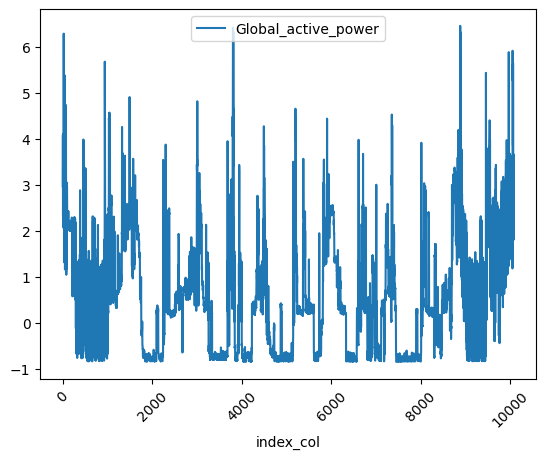

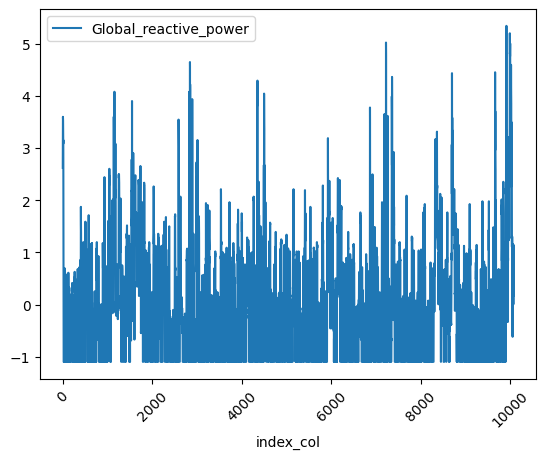

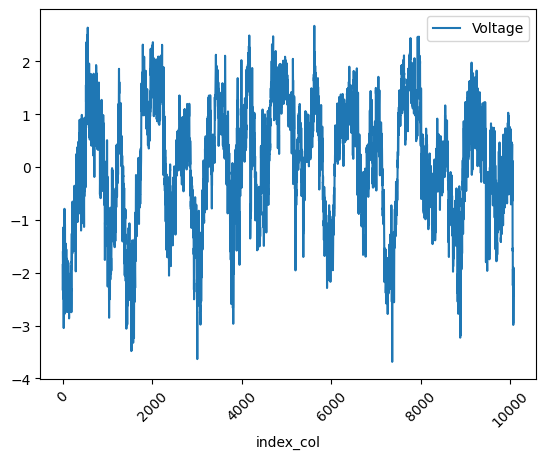

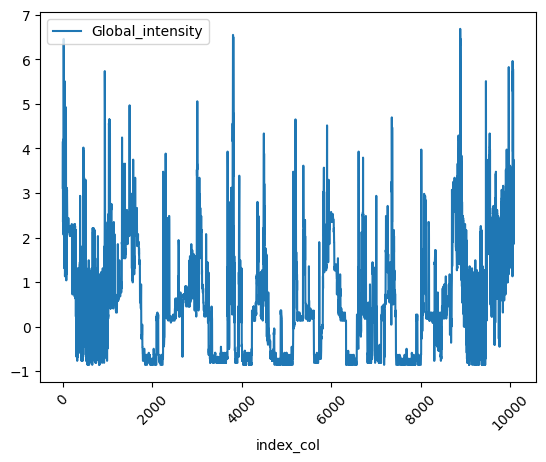

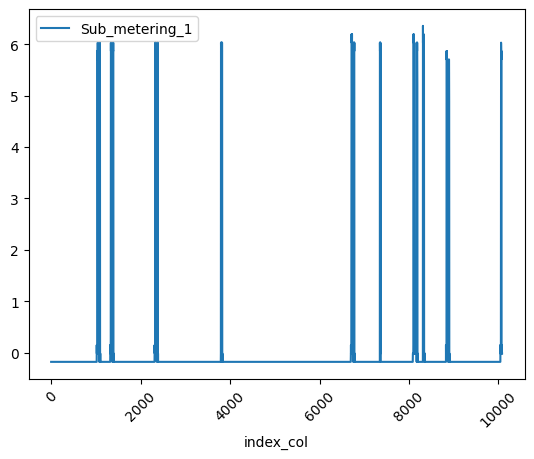

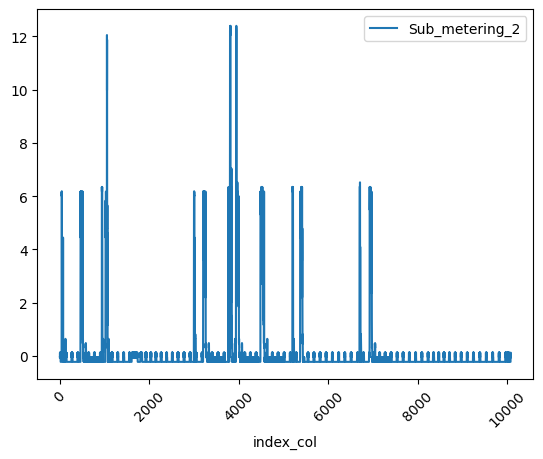

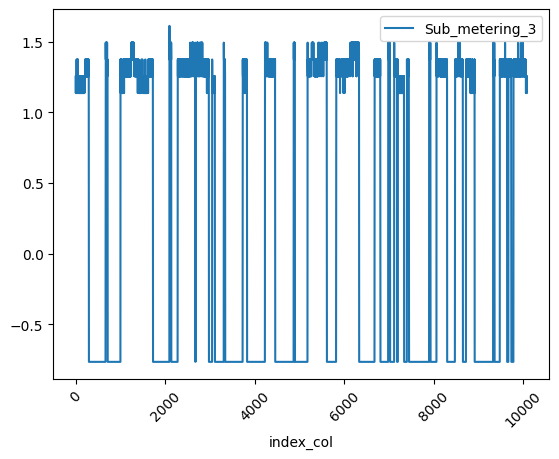

In [18]:
for col in cols:
    ax = df2.iloc[:day*7].plot (x='index_col',y=col) # aqui vemos si hay patrones cada ciertos días
    ax.set_xticklabels(ax.get_xticklabels (), rotation=45)

In [48]:
from statsmodels. tsa.stattools import adfuller

In [49]:
res= adfuller (df2[col].loc[:7*day])
for col in cols:
    res= adfuller (df2[col].loc[:7*day])
    print(f"Col: {col} --> result: {res}")

Col: Global_active_power --> result: (np.float64(-5.444613275292445), np.float64(2.7280775182682318e-06), 39, 10041, {'1%': np.float64(-3.4310014264051087), '5%': np.float64(-2.861827891850243), '10%': np.float64(-2.566923239692562)}, np.float64(11420.598780954075))
Col: Global_reactive_power --> result: (np.float64(-9.054738115100331), np.float64(4.734949726264681e-15), 39, 10041, {'1%': np.float64(-3.4310014264051087), '5%': np.float64(-2.861827891850243), '10%': np.float64(-2.566923239692562)}, np.float64(8046.6039895855865))
Col: Voltage --> result: (np.float64(-4.722568385975601), np.float64(7.631054669306684e-05), 35, 10045, {'1%': np.float64(-3.431001166935527), '5%': np.float64(-2.861827777192639), '10%': np.float64(-2.5669231786601903)}, np.float64(52.80486517598183))
Col: Global_intensity --> result: (np.float64(-5.418452305467499), np.float64(3.0976831922662534e-06), 39, 10041, {'1%': np.float64(-3.4310014264051087), '5%': np.float64(-2.861827891850243), '10%': np.float64(-2

- Vemos como en todos los casos se rechaza la hipótesis nula de que no hay estacionariedad, por tanto sí que hay en el intervalo seleccionado.
- También vemos en las gráficas la seanonality.

# Detrending

In [73]:
df3 = df2.copy()

In [55]:
df3.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'index_col'],
      dtype='object')

In [56]:
df3.dtypes

Date                      object
Time                      object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
index_col                  int64
dtype: object

In [46]:
cols = df3.columns[2:]
cols = cols[:-1]

In [74]:
for col in cols:
    print(col)
    df3[col] = df3[col].diff(day)

Global_active_power
Global_reactive_power
Voltage
Global_intensity
Sub_metering_1
Sub_metering_2
Sub_metering_3


In [49]:
df3.isna().sum()

Date                        0
Time                        0
Global_active_power      1440
Global_reactive_power    1440
Voltage                  1440
Global_intensity         1440
Sub_metering_1           1440
Sub_metering_2           1440
Sub_metering_3           1440
index_col                   0
dtype: int64

In [50]:
df3.shape

(2075259, 10)

In [75]:
df3 = df3.dropna()

In [76]:
df3.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,index_col
1440,17/12/2006,17:24:00,-0.784297,-2.204163,-0.676851,-0.858413,0.0,-0.172805,0.000000,1441
1441,17/12/2006,17:25:00,-1.899025,-2.417469,-0.751026,-1.942724,0.0,-0.172805,0.000000,1442
1442,17/12/2006,17:26:00,-1.874338,-2.986286,-0.132898,-1.897544,0.0,-0.345610,0.000000,1443
1443,17/12/2006,17:27:00,-1.891429,-3.004061,-0.262705,-1.897544,0.0,-0.172805,0.000000,1444
1444,17/12/2006,17:28:00,-0.364613,-3.803959,-1.035365,-0.406617,0.0,-0.172805,-0.118823,1445


In [77]:
df3.to_csv("hosehold_process", index=True)

# Result

In [39]:
five_mins = 5

In [40]:
for col in cols: 
    df3[col] = df3[col].rolling(window=five_mins, center=True).max()
    df3[col] = df3[col] - df3[col]


In [41]:
df3 = df3.dropna()

In [42]:
df3.to_csv("hosehold_process", index=True)

In [117]:
df3.shape

(2075259, 10)